# Neural Network Weights Visualization

Neural Networks at a high-level just consist of matrix multiplications at each layer. Matrix multiplications are linear transformations. This visualization shows the linear transformations at each layer.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib ipympl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from celluloid import Camera
import scienceplots
from IPython.display import Image

torch.manual_seed(0)
np.random.seed(0)
plt.style.use(["science", "no-latex"])

In [2]:
def create_transformations():
    fig, axes = plt.subplots(2, 2, figsize=(16 / 9.0 * 4, 4 * 1), layout="constrained")
    axes = axes.flatten()
    for i, axis in enumerate(axes[:-1]):
        axis.set_title(f"Layer {i}")

    axes[-1].set_title("Mean Squared Error")

    camera = Camera(fig)
    return axes, camera

In [3]:
class TorchNet(nn.Module):
    def __init__(self):
        super(TorchNet, self).__init__()

        # define the layers
        self.fc1 = nn.Linear(2, 2)
        self.fc2 = nn.Linear(2, 2)
        self.fc3 = nn.Linear(2, 1)
        self.layers = [self.fc1, self.fc2, self.fc3]

    def forward(self, x):
        # pass the result of the previous layer to the next layer
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        return self.fc3(x)
        
    def visualize(self, X, y, axes):
        y_cpu = y.detach().numpy()

        cmap = plt.cm.colors.ListedColormap(['red', 'blue'])
        for i, axis in enumerate(axes[:-1]):
            X_cpu = X.detach().numpy() 
            axis.scatter(X_cpu[:, 0], X_cpu[:, 1], c=y, cmap=cmap, alpha=0.5)
            X = F.tanh(self.layers[i](X))

In [4]:
def torch_fit(
    model, features, labels, epochs, learning_rate, output_filename
):
    mse_idx = np.arange(1, epochs + 1)
    errors = np.full(epochs, -1)

    axes, camera = create_transformations()

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.3)

    for idx in range(epochs):
        error = 0
        predictions = np.array([])

        for x, y in zip(features, labels):
            # Forward Propagation
            output = model(x)

            output_np = output.detach().numpy()
            predictions = np.append(predictions, output_np)

            # Store Error
            # tensor(0.) -> tensor([0.])
            y = y.unsqueeze(0)
            loss = loss_fn(output, y)

            error += loss.detach().numpy()

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if (
            idx < 5
            or (idx <= 25 and idx % 5 == 0)
            or (idx <= 1000 and idx % 50 == 0)
            or idx % 250 == 0
        ):

            print(f"epoch: {idx}, MSE: {error}")
            torch_model.visualize(X_tensor, y_tensor, axes)

            # Plot MSE
            mse_ax = axes[-1]
            errors[idx] = error
            visible_mse = errors != -1
            mse_ax.plot(
                mse_idx[visible_mse][: idx + 1],
                errors[visible_mse][: idx + 1],
                color="red",
                alpha=0.5,
            )
            camera.snap()

    animation = camera.animate()
    animation.save(output_filename, writer="pillow")
    plt.show()

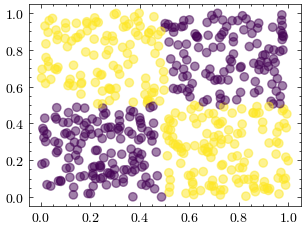

In [5]:
# generate the dataset
def generate_XOR():
    N = 500
    X = np.random.rand(N, 2)
    y = (X[:, 0] > 0.5) != (X[:, 1] > 0.5)

    return X, y

X, y = generate_XOR()

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X[:,0], X[:, 1], c=y, alpha=0.5)

epoch: 0, MSE: 134.6006622314453
epoch: 1, MSE: 130.46102905273438
epoch: 2, MSE: 126.30014038085938
epoch: 3, MSE: 122.29131317138672
epoch: 4, MSE: 119.45194244384766
epoch: 5, MSE: 116.61727905273438
epoch: 10, MSE: 66.36160278320312
epoch: 15, MSE: 64.16358184814453
epoch: 20, MSE: 62.708396911621094
epoch: 25, MSE: 55.70396041870117
epoch: 50, MSE: 16.950462341308594
epoch: 100, MSE: 11.41427993774414
epoch: 150, MSE: 9.138233184814453
epoch: 200, MSE: 7.9905219078063965
epoch: 250, MSE: 7.2700958251953125
epoch: 300, MSE: 6.731736660003662
epoch: 350, MSE: 6.291897773742676
epoch: 400, MSE: 5.920821189880371


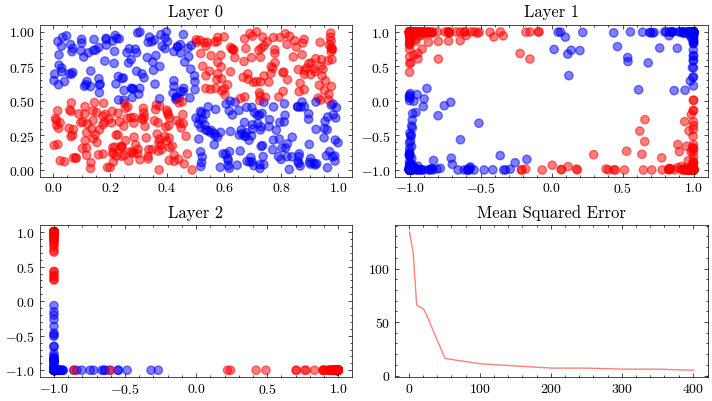

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch_model = TorchNet().to(device)

# the inputs and outputs for PyTorch must be tensors
X_tensor = torch.tensor(X, device=device, dtype=torch.float32).squeeze(-1)
y_tensor = torch.tensor(y, device=device, dtype=torch.float32).squeeze(-1)

epochs = 401
learning_rate = 0.03

output_filename_pytorch = "neural_network_weights.gif"
torch_fit(
    torch_model,
    X_tensor,
    y_tensor,
    epochs,
    learning_rate,
    output_filename_pytorch,
)

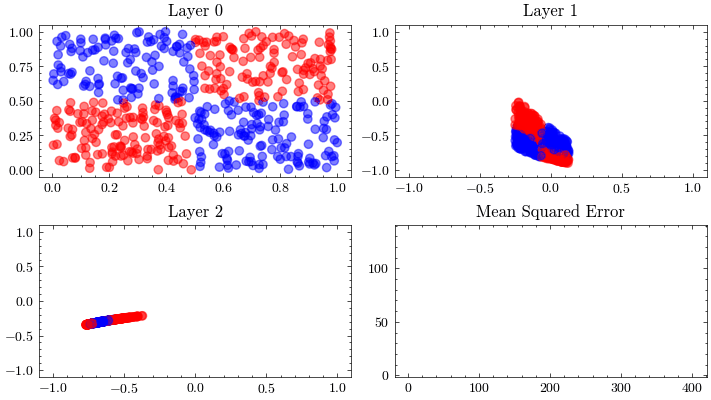

In [7]:
Image(filename=output_filename_pytorch)